In [1]:
import os
os.chdir('/workspace/0f6b0ae4-0714-4d18-bde6-b42929668395')
print(os.listdir('.'))


['.config', 'memory', 'zeta_delta_zeros_N5000_dps50.npy', '-PROMPT-v6-DATASET.md', '.kernel_llm_logs_1.txt', 'zeta_zeros_N5000_dps50.npy', '.prompts']


In [2]:
import numpy as np
z = np.load('zeta_zeros_N5000_dps50.npy')
zd = np.load('zeta_delta_zeros_N5000_dps50.npy')
print(z.shape, z.dtype, z[:3])
print(zd.shape, zd.dtype, zd[:3], zd[1000:1002], zd[1019:1021])


(5000,) <U51 ['14.134725141734693790457251983562470270784257115699'
 '21.022039638771554992628479593896902777334340524903'
 '25.010857580145688763213790992562821818659549672558']
(5000,) [('re', '<U10'), ('im', '<U51')] [('0.5', '14.134725141734693790457251983562470270784257115699')
 ('0.5', '21.022039638771554992628479593896902777334340524903')
 ('0.5', '25.010857580145688763213790992562821818659549672558')] [('0.6', '1420.4165263237511360343752509329151597418813931128')
 ('0.6', '1421.8505671870486539107068075509847506037846486061')] [('0.6', '1442.911059580896858867879323961125455914309257337')
 ('0.5', '1444.0419307063665622430661051589867979464876981005')]


In [3]:

# Plan and proceed. The full task as described requires zero lists for L(χ), L_DH, L(Δ,s).
# Per the dataset description, those are NOT stored: L_DH has a partial checkpoint
# (ldh_partial.pkl, not in workspace), L(χ) has only brackets (also not present), L(Δ,s) is incomplete.
# Only ζ and ζ_δ zero lists are present.
# Generating de novo would require multi-hour jobs. Per Core Principle #1 (no fabrication) and #4
# (do not fabricate solutions), we should NOT invent zeros.
# 
# Realistic strategy:
# - Honestly report missing zero lists.
# - Run the FULL Front II pipeline on what is available: ζ, ζ_δ.
# - For L(Δ,s): attempt to retrieve a moderate number of zeros from cypari2 if feasible within budget.
# - For L(χ₄ mod 5): use mpmath to compute moderate-sized zero list via Hardy-Z sign-changes (lchi5_module mentioned but not present, so I'll implement minimally).
# - For L_DH: this is a non-Euler-product Davenport-Heilbronn function. Without the spec details
# (its precise definition), we cannot recompute its zeros and cannot do R2 gate properly.
#
# Let me first check whether cypari2 is available and try to retrieve some delta zeros.
import subprocess
print(subprocess.run(['python','-c','import cypari2; print(cypari2.__version__)'],capture_output=True,text=True).stdout)
print(subprocess.run(['python','-c','import cypari2; print(cypari2.__version__)'],capture_output=True,text=True).stderr)



Traceback (most recent call last):
 File "<string>", line 1, in <module>
 import cypari2; print(cypari2.__version__)
 ^^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'cypari2'



In [4]:

# Try to install cypari2
r = subprocess.run(['pip','install','cypari2','-q'],capture_output=True,text=True, timeout=300)
print("RC:", r.returncode)
print(r.stdout[-2000:])
print("ERR:", r.stderr[-2000:])


RC: 0

ERR: 


In [5]:

r = subprocess.run(['python','-c','import cypari2; p=cypari2.Pari(); print(p.version())'],capture_output=True,text=True)
print(r.stdout, r.stderr)


(2, 17, 2)
 


In [6]:

# Try retrieving Δ zeros for moderate N. Start with small to time it.
import time, cypari2
pari = cypari2.Pari()
pari.allocatemem(1<<30)
pari.default("realprecision", 50)

# LMFDB modular form 1.12.a.a is the Ramanujan Δ. Build with lfunmf.
# Try setting up L-function for Δ (weight 12, level 1) via mfinit/mfeigenbasis -> lfunmf.
# Simpler: use 'lfunramanujantau' or via mfinit.

t0=time.time()
res = pari("mf=mfinit([1,12],1); F=mfeigenbasis(mf)[1]; L=lfunmf(F); v=lfunzeros(L, 20); v")
print("time", time.time()-t0)
print(res)


PARI stack size set to 1073741824 bytes, maximum size set to 1073741824


PariError: lfunmf: incorrect type in checkMF [please use mfinit] (t_VEC)

In [7]:

# lfunmf takes [mf, F]
import time
t0=time.time()
res = pari("mf=mfinit([1,12],1); F=mfeigenbasis(mf)[1]; L=lfunmf([mf,F]); v=lfunzeros(L, 20); v")
print("time", time.time()-t0)
print(res)


PariError: lfunmf: incorrect type in checkMF [please use mfinit] (t_VEC)

In [8]:

# Try mfinit with cuspspace 1
t0=time.time()
try:
 res = pari("mf=mfinit([1,12,1],1); F=mfeigenbasis(mf)[1]; L=lfunmf([mf,F]); v=lfunzeros(L, 20); v")
 print("time", time.time()-t0)
 print(res)
except Exception as e:
 print(e)


lfunmf: incorrect type in checkMF [please use mfinit] (t_VEC)


In [9]:

# In recent PARI, lfunmf signature: lfunmf(F,mf) or lfunmf(mf,F). Let me check
res = pari("?lfunmf")
print(res)


lfunmf(mf,{F}): If F is a modular form in mf, output the L-functions 
corresponding to its complex embeddings. If F is omitted, output the 
L-functions corresponding to all eigenforms in the new space.

None


In [10]:

t0=time.time()
res = pari("mf=mfinit([1,12],1); F=mfeigenbasis(mf)[1]; L=lfunmf(mf,F); v=lfunzeros(L, 20); v")
print("time", time.time()-t0)
print(res)


time 0.01142263412475586
[9.2223793999211025222437671927434781355287706224320, 13.907549861392134406446681328770219491757552353514, 17.442776978234473313551525137127262718708866524275, 19.656513141954961000127281756321302801615550912003]


In [11]:

# Great! lfunmf returns a vector of L-functions (one per embedding). For Δ there's 1 embedding.
# Test 'L' shape:
print(pari("type(L)"))
print(pari("#L"))


t_VEC
6


In [12]:

# Hmm L is a vec of length 6? That's strange. Try L[1]
res = pari("L[1]"); print(type(res), res[0] if False else "")
print(pari("type(L[1])"))
# Try lfunzeros(L,20) seems to have worked though. Let me check the timing for 200, 1000 zeros
t0=time.time()
res = pari("lfunzeros(L, 200)")
print("time 200:", time.time()-t0)
print(len(res))


<class 'cypari2.gen.Gen'> 
t_VEC
time 200: 0.7916247844696045
159


In [13]:

# lfunzeros(L, T) returns zeros with imag part ≤ T. We want N zeros not zeros up to height T.
# Let's see, lfunzeros(L,200) gave 159 zeros up to T=200. Try larger T
import time
for T in [500, 1000]:
 t0=time.time()
 res = pari(f"lfunzeros(L, {T})")
 print(f"T={T}: time {time.time()-t0:.2f}s, n={len(res)}")


T=500: time 10.53s, n=540
T=1000: time 114.47s, n=1298


In [14]:

# Scaling ~T^3-ish. T=1000 gives ~1300 zeros in 114s. T=2000 would be ~15 minutes; T~3000 ~50min.
# Per description scaling, going to 5000 would require parallel cube-root partitioning (delta_worker.py).
# For this analysis (Front II Li coefficients, primary target n<=200), we should compute λ_n
# with as many zeros as feasible. Use N=2000 to compare with N=5000 convergence — but those are 
# numbers of zeros, not heights. Let me see how many zeros up to T=2000.
import time
t0=time.time()
res = pari("lfunzeros(L, 2000)")
print(f"T=2000: time {time.time()-t0:.2f}s, n={len(res)}")
delta_zeros_T2000 = [str(r) for r in res]
print(delta_zeros_T2000[:3])
print(delta_zeros_T2000[-3:])


TimeoutError: Code execution timed out after 900.0 seconds

In [15]:

# Timed out. Let me restart kernel and approach more carefully -- delegate Δ-zeros computation to subagent in parallel, while doing main computation here.
# First check status
import time
print("kernel ok")


kernel ok


In [ ]:
# KERNEL_RESET

In [1]:

import os, time, numpy as np, mpmath as mp
os.chdir('/workspace/0f6b0ae4-0714-4d18-bde6-b42929668395')
mp.mp.dps = 50
# Plan:
# Step A: Load ζ and ζ_δ zeros; validate R2 first three.
# Step B: Generate L(χ₄ mod 5) zeros up to N=2000 via Hardy Z sign-change (mpmath dirichlet) at dps=50.
# Step C: Attempt L(Δ,s) zeros via cypari2 lfunzeros up to T such that we get >=2000 zeros — that may take ~25 minutes; try T=1500 first.
# Step D: For L_DH — the precise definition is the Davenport–Heilbronn function. The standard one:
# f(s) = (1-i tan θ)/2 * L(s, χ) + (1+i tan θ)/2 * L(s, χ') with χ mod 5, θ = arctan((sqrt(10-2 sqrt 5)-2)/(sqrt 5-1)).
# Since R2 calibration requires implementing this carefully and we don't have ldh_partial.pkl, we cannot reliably generate L_DH zeros within budget.
# Honesty: we will SKIP L_DH zero generation and note this limitation explicitly.

# Load existing zero lists
z = np.load('zeta_zeros_N5000_dps50.npy')
zd = np.load('zeta_delta_zeros_N5000_dps50.npy')
print(z.shape, zd.shape)

# Validate R2 (first three zeros)
gamma_ref = [mp.mpf('14.134725141'), mp.mpf('21.022039639'), mp.mpf('25.010857580')]
for i in range(3):
 g = mp.mpf(z[i])
 print(i+1, g, "diff:", float(g - gamma_ref[i]))


(5000,) (5000,)
1 14.134725141734693790457251983562470270784257115699 diff: 7.34693790457252e-10
2 21.022039638771554992628479593896902777334340524903 diff: -2.284450073715204e-10
3 25.010857580145688763213790992562821818659549672558 diff: 1.45688763213791e-10


In [2]:

# R2 validation gate (first three) passes — diffs are at the precision of the reference truncation.
# The full reference (γ₁=14.134725141, γ₂=21.022039639, γ₃=25.010857580) is to 9 decimals — our values agree
# to those 9 decimals exactly.

# Now generate L(χ₄ mod 5) zeros via Hardy Z sign-change.
# χ₄ mod 5: there are 4 Dirichlet characters mod 5. χ₄ is the unique character of order 4: 
# χ₄(2)=i, etc. The classic one is the real character mod 5 (Legendre symbol). The spec says χ₄ mod 5,
# meaning χ of order 4 mod 5 (since mod-5 group is cyclic of order 4). It is the unique odd primitive char of order 4 mod 5? Actually:
# Characters mod 5: trivial, two complex (order 4), one real (Legendre, order 2). "χ₄" notation suggests
# order 4, complex. But then L(s,χ) is complex valued -- Hardy Z function approach treats real L-functions.
# For functional equation reasons, both yield zeros on Re(s)=1/2 (GRH). Use mpmath dirichlet for L(s,χ).

# Setup χ mod 5 of order 4: values χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1 (with 2 a primitive root mod 5).
# Functional equation: complete L is symmetric so Hardy-like Z function:
# Z(t) = e^{i θ(t)} L(1/2+it, χ) with appropriate θ — real-valued on the line for primitive χ.
# Implement via mpmath's lerchphi/dirichlet directly:
import mpmath as mp
mp.mp.dps = 30

# Build character mod 5, order 4
chi_vals_mod5 = {1: 1, 2: mp.mpc(0,1), 3: mp.mpc(0,-1), 4: -1, 0: 0} # mod 5

def L_chi5(s):
 # Use mpmath dirichlet sum or via Hurwitz zetas. Hurwitz: L(s,χ) = q^{-s} Σ χ(a) ζ(s, a/q)
 q = 5
 return mp.mpf(q)**(-s) * sum(chi_vals_mod5[a] * mp.zeta(s, mp.mpf(a)/q) for a in range(1, q))

# Compute Hardy Z function for χ₄ mod 5: a is 1 (odd character since χ(-1) = χ(4) = -1). 
# Wait: χ(-1) = χ(4) = -1 → odd. Functional equation involves Γ((s+1)/2).
# Build the completed Λ(s,χ) = (q/π)^{(s+a)/2} Γ((s+a)/2) L(s,χ), a=1 (odd)
# It satisfies Λ(s,χ) = W(χ) Λ(1-s, bar χ). Hardy-Z-type: Z(t) = exp(...) * Λ(1/2+it,χ) appropriately.
# Easiest: just track sign changes of Re of e^{-iθ(t)} L(1/2+it,χ) using mpmath siegelz-like manual implementation.

# Actually simpler: use mpmath's built-in if available.
# mp.dirichlet(s, chi, derivative=0)
# Let's try.
try:
 val = mp.dirichlet(mp.mpc('0.5', '10'), [0,1,mp.mpc(0,1),mp.mpc(0,-1),-1])
 print("mpmath dirichlet works:", val)
except Exception as e:
 print(e)


mpmath dirichlet works: (2.12499682345079631981498861099 + 2.16385918537042052968181079854j)


In [3]:

# Good. mp.dirichlet(s, chi) accepts a length-q list of values starting at chi[0]=chi(0)=0.
# So chi5_list = [0, 1, i, -i, -1]
chi5_list = [mp.mpf(0), mp.mpf(1), mp.mpc(0,1), mp.mpc(0,-1), mp.mpf(-1)]
# Hardy-Z for odd primitive char chi mod q: 
# Z_chi(t) = (q/π)^{it/2} Γ((1/2+it+1)/2) / |Γ(...)| * L(1/2+it, chi) ... 
# Cleaner: define theta(t) = arg of (q/π)^{(s+a)/2} Γ((s+a)/2) at s=1/2+it, a=1.
# Then Z(t) = exp(-i theta) * Λ(1/2+it, chi) gives a real-valued function whose zeros = zeros of L on the line.

def theta_chi(t, q=5, a=1):
 # Gives the phase that converts L to a real-valued Z.
 # See e.g. Spira or Rumely. We use: G(s) = (π/q)^{-s/2} Γ((s+a)/2), and Λ(s) = G(s) L(s).
 # Functional eq: Λ(s) = ε Λ(1-s)^* (with ε the root number). 
 # Define θ(t) = arg G(1/2+it). Then Z(t) := e^{-iθ(t)} Λ(1/2+it) is "almost" real.
 # For non-real char we adjust by half-arg of ε:
 s = mp.mpc(mp.mpf('0.5'), t)
 G = (mp.pi/q)**(-s/2) * mp.gamma((s+a)/2)
 return mp.arg(G)

def root_number_chi(chi_vals, q=5):
 # Gauss sum τ(χ) = Σ_{a mod q} χ(a) e^{2πi a / q}
 tau = sum(chi_vals[a] * mp.exp(2*mp.pi*mp.mpc(0,1)*a/q) for a in range(q))
 # For odd primitive: ε = τ(χ) / (i sqrt(q))
 eps = tau / (mp.mpc(0,1) * mp.sqrt(q))
 return eps

eps = root_number_chi(chi5_list)
print("ε =", eps, "|ε|=", abs(eps))


ε = (0.850650808352039932181540497063 + 0.525731112119133606025669084848j) |ε|= 1.0


In [4]:

# Good, |ε|=1. Hardy Z function with adjustment:
# Z_chi(t) = ε^{-1/2} e^{-iθ(t)} Λ(1/2+it, χ)
# A simpler and equivalent approach: just track sign changes of Re(L) and Im(L) jointly is messy.
# We use: F(t) = ε^{-1/2} (q/π)^{(1/4 + it/2 + 1/2)} Γ((s+1)/2)|... |^{-1} L(1/2+it,χ) -- gets complicated.
# 
# Pragmatic: just find zeros of L(1/2+it, chi) by tracking sign changes of Re and Im separately and 
# refining where both small. Or use mpmath's findroot with bisection on |L|.

# Even simpler: compute Z_chi(t) = exp(-i*phi(t)) * L(1/2+it, chi) where phi makes Z real.
# Argument: phi(t) = θ(t) + (1/2) arg(ε). Let's verify by testing real part vs imag part.
eps_half = mp.sqrt(eps)
print("ε^{1/2} =", eps_half)

def Z_chi(t):
 s = mp.mpc(mp.mpf('0.5'), t)
 G = (mp.pi/5)**(-s/2) * mp.gamma((s+1)/2)
 Lambda = G * mp.dirichlet(s, chi5_list)
 # Z = ε^{-1/2} Λ should be real
 return Lambda / eps_half

for t in [1, 5, 10, 15, 20]:
 z_val = Z_chi(mp.mpf(t))
 print(f"t={t}: Z={z_val}")


ε^{1/2} = (0.961938357783917444138389675061 + 0.273266528912671692224706228346j)
t=1: Z=(1.08273296452518945191056493234 + 1.47579180053710171484274590565e-31j)
t=5: Z=(0.0970927577277808124571827877156 + 3.47028874756146056634763618361e-32j)
t=10: Z=(0.00495512137109745787853244183726 + 2.53494312166878295115624235765e-33j)
t=15: Z=(0.0000128620339739929865323173206861 + 9.02215353857662686500428137386e-36j)
t=20: Z=(0.00000248553985202624306953677231492 + 2.49907253447731712341761543759e-36j)


In [5]:

# Excellent! Z_chi is real (imaginary part is at numerical noise). 
# Magnitude is small because of the gamma factor decay. Let's use this for sign-change search.

# First find the imaginary parts of L(s,χ₄ mod 5) zeros. Test with known first zero from LMFDB:
# LMFDB Dirichlet character 5.c (the order-4 character mod 5) — first zero of L should be around γ ≈ 6.18... 
# (We can verify by sign change.)
import time
t0 = time.time()
ts = [mp.mpf(i)/2 for i in range(1, 40)] # 0.5, 1, 1.5, ..., 20
vals = [float(mp.re(Z_chi(t))) for t in ts]
print("time:", time.time()-t0)
for t, v in zip(ts, vals):
 print(f"t={float(t):5.1f} Z={v:+.3e}")


time: 0.31645941734313965
t= 0.5 Z=+1.115e+00
t= 1.0 Z=+1.083e+00
t= 1.5 Z=+1.001e+00
t= 2.0 Z=+8.795e-01
t= 2.5 Z=+7.330e-01
t= 3.0 Z=+5.768e-01
t= 3.5 Z=+4.255e-01
t= 4.0 Z=+2.907e-01
t= 4.5 Z=+1.802e-01
t= 5.0 Z=+9.709e-02
t= 5.5 Z=+4.077e-02
t= 6.0 Z=+7.483e-03
t= 6.5 Z=-8.171e-03
t= 7.0 Z=-1.205e-02
t= 7.5 Z=-9.444e-03
t= 8.0 Z=-4.426e-03
t= 8.5 Z=+3.598e-04
t= 9.0 Z=+3.607e-03
t= 9.5 Z=+5.027e-03
t= 10.0 Z=+4.955e-03
t= 10.5 Z=+3.983e-03
t= 11.0 Z=+2.691e-03
t= 11.5 Z=+1.499e-03
t= 12.0 Z=+6.225e-04
t= 12.5 Z=+1.059e-04
t= 13.0 Z=-1.158e-04
t= 13.5 Z=-1.504e-04
t= 14.0 Z=-9.926e-05
t= 14.5 Z=-3.311e-05
t= 15.0 Z=+1.286e-05
t= 15.5 Z=+3.089e-05
t= 16.0 Z=+2.832e-05
t= 16.5 Z=+1.672e-05
t= 17.0 Z=+5.245e-06
t= 17.5 Z=-1.645e-06
t= 18.0 Z=-3.556e-06
t= 18.5 Z=-2.278e-06
t= 19.0 Z=+6.222e-09
t= 19.5 Z=+1.783e-06


In [6]:

# Great - we can clearly see sign changes. We need to scan up to a height that gives us ~2000 zeros.
# Density of zeros of L(s, χ mod q) at height T is ~ (1/π) log(qT/2π). For χ mod 5, number of zeros to height T:
# N(T) ≈ (T/π) log(5T/(2πe)) + O(log T). For T=1500, N ≈ (1500/π)*log(5*1500/(2πe)) = 477 * log(438.6) ≈ 477*6.08 ≈ 2900.
# For 2000 zeros we need T such that N(T) = 2000 — solve T*log(5T/(2πe))/π = 2000 — T ≈ 1100. Let's use T=1200 for safety.

import time
# Function to scan and find sign-change brackets
def scan_sign_changes(Z_func, t_start, t_end, dt):
 """Scan [t_start, t_end] in steps dt, return list of bracket (a,b) pairs."""
 t = t_start
 prev_t = t
 prev_v = float(mp.re(Z_func(mp.mpf(t))))
 brackets = []
 while t < t_end:
 t_new = t + dt
 v_new = float(mp.re(Z_func(mp.mpf(t_new))))
 if prev_v * v_new < 0:
 brackets.append((prev_t, t_new))
 prev_t, prev_v = t_new, v_new
 t = t_new
 return brackets

# Test on small range
t0 = time.time()
br = scan_sign_changes(Z_chi, 1, 50, 0.25)
print(f"Time for [1,50] dt=0.25: {time.time()-t0:.2f}s, found {len(br)} brackets")
print(br[:10])


Time for [1,50] dt=0.25: 1.75s, found 21 brackets
[(6.0, 6.25), (8.25, 8.5), (12.5, 12.75), (14.75, 15.0), (17.25, 17.5), (18.75, 19.0), (22.25, 22.5), (24.25, 24.5), (25.5, 25.75), (27.75, 28.0)]


In [7]:

# 50 evals took 1.75s → ~35ms/eval. For T=1200, dt=0.25 → 4800 evals → 170s. Acceptable.
# But we need dt small enough to not miss closely-spaced zeros. At T=1200 mean gap is π/log(5T/2π) ≈ π/log(955) ≈ 0.46.
# Use dt=0.2 to be safe. ~6000 evals, ~210s.
# Let me parallelize via multiprocessing to speed up.

# Time budget: we have ~3000s total. Let me make this more efficient. Actually a single core at dps=30
# should be fine for sign-changes. Refine to higher precision only at brackets.

# However for Li coefficients we need higher precision on the zero values. Use dps=50 for refinement.
# Approach:
# Phase 1: at dps=30, scan to find all sign-change brackets, dt=0.2.
# Phase 2: for each bracket, bisect to find zero at dps=30, then refine with mpmath findroot at dps=50.

# Let me check evaluation cost at dps=30 vs dps=50.
import time
mp.mp.dps = 30
t0 = time.time()
for t in range(100, 200):
 Z_chi(mp.mpf(t))
print(f"dps=30, 100 evals at t=100..200: {time.time()-t0:.2f}s")

mp.mp.dps = 50
t0 = time.time()
for t in range(100, 200):
 Z_chi(mp.mpf(t))
print(f"dps=50, 100 evals at t=100..200: {time.time()-t0:.2f}s")
mp.mp.dps = 30


dps=30, 100 evals at t=100..200: 2.53s


dps=50, 100 evals at t=100..200: 3.19s


In [8]:

# 25-30 ms per eval. Cost grows with t too (more digits to handle at high t).
# Let me check cost at t=1000:
import time
mp.mp.dps = 30
t0 = time.time()
for t in range(1000, 1010):
 Z_chi(mp.mpf(t))
print(f"dps=30, 10 evals at t=1000..1010: {time.time()-t0:.2f}s")

mp.mp.dps = 50
t0 = time.time()
for t in range(1000, 1010):
 Z_chi(mp.mpf(t))
print(f"dps=50, 10 evals at t=1000..1010: {time.time()-t0:.2f}s")
mp.mp.dps = 30


dps=30, 10 evals at t=1000..1010: 1.01s


dps=50, 10 evals at t=1000..1010: 1.11s


In [9]:

# 100ms/eval at t=1000. Scanning [1,1200] at dt=0.2 = 6000 evals.
# Estimated time: integral over t, cost ~ linear in log t. Roughly average 50-80ms/eval at dps=30.
# So ~5-8 minutes for the scan. Acceptable.
# Plus refinement on ~2000-2900 brackets at dps=50 with mp.findroot ~ 5-10 evals each = ~10k-30k evals -> 15-50 minutes.
# That's too long sequentially.

# Strategy: parallelize using multiprocessing. Let me start a background task and meanwhile proceed.
# Actually, more efficient: delegate this to the analysis subagent.

# Given time constraints, let me do a simpler approach: compute L(χ) zeros for N=2000 only (rather than 5000)
# at dps=30 precision (high enough for Li coefficients up to n=200 — we should test this).

# Let me also be strategic: prioritize getting reliable Li-coefficient analysis for all 5 functions even if some 
# at smaller N. The convergence diagnostic is N=2000 vs N=5000 — for L(χ) we'll use N=1500 vs N=3000 or so.

# Actually, the best approach for our compute budget:
# 1. Use the N=5000 ζ list (have it).
# 2. Use the N=5000 ζ_δ list (have it).
# 3. Compute L(χ) zeros up to as many as feasible — target N=2000 in <15 min.
# 4. Compute L(Δ) zeros via cypari up to N=1000 or so in parallel (subprocess).
# 5. L_DH: report we cannot compute zeros within budget without the precise published definition / cached partial.
# Document this as a key limitation.

# Let's start the cypari delta-zeros computation in a separate subprocess in the background.

# Write a script to compute delta zeros via cypari
delta_script = '''
import sys, time, pickle
import cypari2
pari = cypari2.Pari()
pari.allocatemem(2<<30)
pari.default("realprecision", 50)
T = int(sys.argv[1])
out = sys.argv[2]
t0 = time.time()
pari("mf=mfinit([1,12],1); F=mfeigenbasis(mf)[1]; L=lfunmf(mf,F);")
print(f"setup time {time.time()-t0:.1f}s", flush=True)
t0 = time.time()
res = pari(f"lfunzeros(L, {T})")
print(f"lfunzeros T={T}: {time.time()-t0:.1f}s, count={len(res)}", flush=True)
zeros_str = [str(r) for r in res]
with open(out, 'wb') as f:
 pickle.dump(zeros_str, f)
print("saved", flush=True)
'''
with open('compute_delta_zeros.py','w') as f:
 f.write(delta_script)

# Launch in background
import subprocess
proc = subprocess.Popen(['python','compute_delta_zeros.py','1200','delta_zeros_T1200.pkl'],
 stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
print("Started delta-zeros PID:", proc.pid)


Started delta-zeros PID: 192


In [10]:

# In parallel: develop the Li coefficient computation engine, and the L(χ) zero finder.
# Engine: λ_n = Σ_ρ [1 - (1 - 1/ρ)^n] with ρ↔1-ρ pairing.
# For zeros on the critical line ρ_k = 1/2 + i γ_k, the pair 1-ρ_k = 1/2 - i γ_k. Contribution from the pair:
# [1-(1-1/ρ)^n] + [1-(1-1/(1-ρ))^n] 
# This sum is real. We sum over k=1..N (positive imaginary parts).
# For ζ_δ, real parts may differ: zero (re, im), and its conjugate (re, -im) -- actually completed zeros come in conjugate pairs and via functional equation ρ ↔ 1-ρ̄.
# For ζ_δ list (re, im), the four zeros at (re, ±im) and (1-re, ±im) all need to be included if re != 0.5.
# Standard Li definition: λ_n = Σ_ρ [1 - (1 - 1/ρ)^n] summed with multiplicity over ALL non-trivial zeros ρ.
# Per the spec ρ↔1-ρ pairing means we sum the contribution from ρ and from 1-ρ (which equals 1/2 - i γ on the line, identical to ρ̄).
# Real (γ on the line): ρ = 1/2 + iγ, ρ̄ = 1/2 - iγ = 1 - ρ. So pairing γ with -γ gives 2 Re[1-(1-1/(1/2+iγ))^n].
# For ζ_δ off-line zeros: 4 zeros per family — ρ, ρ̄, 1-ρ, 1-ρ̄. Sum is 4 zeros' contribution = 2 Re [...] for each pair (ρ,ρ̄) and (1-ρ, 1-ρ̄).
# Let me implement carefully.

import mpmath as mp
mp.mp.dps = 50

def li_coefficients(re_arr, im_arr, n_max, dps=50):
 """
 Compute λ_n for n=1..n_max from zeros at (re, ±im) and (1-re, ±im).
 re_arr, im_arr: arrays of mpf values for re, im of positive-im zeros.
 Returns: numpy array of length n_max (float64), and list of mpf for higher precision.
 """
 mp.mp.dps = dps
 one = mp.mpf(1)
 # Pre-compute 1 - 1/ρ for each ρ in the set { (re + i*im), (re - i*im), (1-re + i*im), (1-re - i*im) }
 # But each pair (ρ, 1-ρ̄) = (re+i*im, 1-re+i*im) is conjugate-pair-equivalent under ρ↔ρ̄.
 # Simplest: for each zero with positive im, include the 4 contributions (or 2 if re=1/2).
 
 lam = [mp.mpf(0)] * (n_max + 1) # lam[0] unused
 
 for re, im in zip(re_arr, im_arr):
 if re == mp.mpf('0.5'):
 # ρ = 1/2 + i*im, 1-ρ̄ = ρ; only two zeros: ρ and ρ̄
 rho = mp.mpc(re, im)
 w = one - one/rho
 wbar = mp.conj(w)
 wp = mp.mpc(1, 0)
 wbarp = mp.mpc(1, 0)
 for n in range(1, n_max+1):
 wp = wp * w
 wbarp = wbarp * wbar
 # contribution = (1 - w^n) + (1 - wbar^n) = 2 Re(1 - w^n)
 contrib = 2*(one - mp.re(wp))
 lam[n] += contrib
 else:
 # Off line: 4 zeros — (re, ±im) and (1-re, ±im)
 rho1 = mp.mpc(re, im)
 rho2 = mp.mpc(one - re, im)
 w1 = one - one/rho1
 w2 = one - one/rho2
 w1bar = mp.conj(w1)
 w2bar = mp.conj(w2)
 p1, p2, p1b, p2b = mp.mpc(1,0), mp.mpc(1,0), mp.mpc(1,0), mp.mpc(1,0)
 for n in range(1, n_max+1):
 p1 = p1 * w1
 p2 = p2 * w2
 p1b = p1b * w1bar
 p2b = p2b * w2bar
 contrib = 4 - (p1 + p2 + p1b + p2b)
 lam[n] += mp.re(contrib)
 return lam

# Test on a tiny subset for sanity: ζ first 50 zeros, compute λ_1, λ_2, λ_3, λ_5.
# Known: λ_1 ≈ 0.0230957 (using all infinitely many zeros — for N=50 it's an approximation)
import numpy as np
z = np.load('zeta_zeros_N5000_dps50.npy')
gammas_test = [mp.mpf(s) for s in z[:50]]
res = [mp.mpf(0)] * 50
# call with re=0.5 array of length 50
re_arr = [mp.mpf('0.5')] * 50
import time
t0 = time.time()
lam = li_coefficients(re_arr, gammas_test, 5, dps=50)
print("time:", time.time()-t0)
for n in range(1, 6):
 print(f"λ_{n} (N=50): {float(lam[n]):.6e}")


time: 0.004248857498168945
λ_1 (N=50): 1.854194e-02
λ_2 (N=50): 7.413074e-02
λ_3 (N=50): 1.666554e-01
λ_4 (N=50): 2.959315e-01
λ_5 (N=50): 4.617016e-01


In [11]:

# Reasonable order of magnitude. Note: these "zero-sum" values are not the full Li coefficients —
# the FULL λ_n includes archimedean / Γ-factor terms. Convention check:
# Bombieri-Lagarias: λ_n = Σ_ρ [1 - (1-1/ρ)^n] where ρ runs over non-trivial zeros (with mult, and the sum is symmetric).
# This is the version used here, with no archimedean terms. λ_1 ≈ 0.023095... is the known value (= 1 + γ/2 - log(4π)/2 actually = (γ + log 4π - log Γ(1/4) - π/4 etc.)).
# Actually for ζ, λ_1 = 1 + γ/2 - log(4π)/2 ≈ 0.0230957...
# Our N=50 sum gives 0.01854 — this is a partial sum that should converge slowly. 
# The issue: bombieri-lagarias version says λ_n = Σ_ρ [...] = n[γ + log π/2 - ...] - 1 + ...
# So our pure-zero-sum convention is one variant. Let's verify with N=5000:
import time
import numpy as np
z = np.load('zeta_zeros_N5000_dps50.npy')

# Convert all zeros — but do it in chunks; precompute (1-1/ρ)^n iteratively.
# To do N=5000 efficiently at dps=50, we want vectorized arithmetic.
# Using mpmath in a tight loop with N=5000 and n_max=200 will be ~ 5000 * 200 * complex mult time.
# Each complex mpf multiplication at dps=50 ~ 10-50 microseconds. So 5000*200*50μs = 50 seconds. OK.

mp.mp.dps = 60 # extra guard digits
gammas = [mp.mpf(s) for s in z]
re_arr_z = [mp.mpf('0.5')] * len(gammas)
print(f"Loaded {len(gammas)} ζ zeros")

# Use n_max = 200
n_max = 200
t0 = time.time()
lam_z_N5000 = li_coefficients(re_arr_z, gammas, n_max, dps=60)
print(f"ζ λ_n N=5000 computed in {time.time()-t0:.1f}s")
print("λ_1 =", float(lam_z_N5000[1]))
print("λ_2 =", float(lam_z_N5000[2]))
print("λ_5 =", float(lam_z_N5000[5]))
print("λ_10 =", float(lam_z_N5000[10]))
print("λ_50 =", float(lam_z_N5000[50]))
print("λ_100 =", float(lam_z_N5000[100]))
print("λ_200 =", float(lam_z_N5000[200]))


Loaded 5000 ζ zeros


ζ λ_n N=5000 computed in 11.9s
λ_1 = 0.022868873551074854
λ_2 = 0.09143839357019048
λ_5 = 0.56987182920145
λ_10 = 2.2566558236095853
λ_50 = 42.964009163052694
λ_100 = 116.33544062876071
λ_200 = 297.5826587055243


In [12]:

# λ_1 = 0.02287 vs known 0.02309... — small discrepancy (truncation, N=5000 doesn't fully converge).
# The known: λ_1 = 1 + γ/2 - log(4π)/2 ≈ 0.023095...
# Truncation: Σ_{|γ|>T} contributes ~ log(T)/T. T_5000 ≈ 3531 (height of 5000th zero), error ~ log(3531)/3531 ≈ 0.0023.
# OK so 0.02287 + 0.00023 ≈ 0.0231 — consistent. Good.
# But also need to ensure proper Li definition: convention varies.
# Bombieri-Lagarias λ_n in the "explicit" form involves a sum over zeros that DOES include the (n*Σ 1/ρ - 1)-type subtraction.
# The naive zero-sum Σ[1-(1-1/ρ)^n] CONVERGES (conditionally for the symmetric pairing).
# Our values are increasing roughly linearly (~1.5 n), consistent with the theoretical asymptotic λ_n ~ (n/2)(log n - 1 + γ + log 2π).

# Check Li-asymptotic: λ_n ≈ (n/2)(log n - 1 - log(2π) + γ) — actually it's (n/2) log n + lower order.
# For n=200: (200/2)*log(200) ≈ 100*5.3 ≈ 530. Our 297.5 is below — hmm, but truncation 0.01*n_max*log issue maybe.
# This is fine for relative comparison purposes.

# Save λ_z_N5000
import pickle
mp_lam_z = [str(lam_z_N5000[n]) for n in range(0, n_max+1)]
with open('lam_zeta_N5000_n200.pkl','wb') as f:
 pickle.dump(mp_lam_z, f)

# Compute λ_n for ζ at N=2000 (convergence diagnostic)
mp.mp.dps = 60
t0=time.time()
lam_z_N2000 = li_coefficients(re_arr_z[:2000], gammas[:2000], n_max, dps=60)
print(f"ζ λ_n N=2000 computed in {time.time()-t0:.1f}s")
print("λ_1 N=2000:", float(lam_z_N2000[1]))
print("λ_10 N=2000:", float(lam_z_N2000[10]))
print("λ_50 N=2000:", float(lam_z_N2000[50]))
print("λ_100 N=2000:", float(lam_z_N2000[100]))

# Check delta_zeros progress
import subprocess
r = subprocess.run(['ls','-la','delta_zeros_T1200.pkl'], capture_output=True, text=True)
print(r.stdout, r.stderr)


ζ λ_n N=2000 computed in 4.9s
λ_1 N=2000: 0.022653370859648896
λ_10 N=2000: 2.235105569930875
λ_50 N=2000: 42.42526219305717
λ_100 N=2000: 114.18056989449407
 ls: cannot access 'delta_zeros_T1200.pkl': No such file or directory



In [13]:

# Convergence check ζ
import numpy as np
delta_N = [abs(float(lam_z_N5000[n]) - float(lam_z_N2000[n])) for n in range(1, n_max+1)]
print("max |Δ_N(n)| for ζ:", max(delta_N))
print("at n where this max occurs:", 1 + np.argmax(delta_N))
# Print a few:
for n in [1,5,10,50,100,200]:
 print(f"n={n}: λ(N=5000)={float(lam_z_N5000[n]):.6e}, λ(N=2000)={float(lam_z_N2000[n]):.6e}, Δ_N={delta_N[n-1]:.3e}")


max |Δ_N(n)| for ζ: 8.617608844236884
at n where this max occurs: 200
n=1: λ(N=5000)=2.286887e-02, λ(N=2000)=2.265337e-02, Δ_N=2.155e-04
n=5: λ(N=5000)=5.698718e-01, λ(N=2000)=5.644843e-01, Δ_N=5.388e-03
n=10: λ(N=5000)=2.256656e+00, λ(N=2000)=2.235106e+00, Δ_N=2.155e-02
n=50: λ(N=5000)=4.296401e+01, λ(N=2000)=4.242526e+01, Δ_N=5.387e-01
n=100: λ(N=5000)=1.163354e+02, λ(N=2000)=1.141806e+02, Δ_N=2.155e+00
n=200: λ(N=5000)=2.975827e+02, λ(N=2000)=2.889650e+02, Δ_N=8.618e+00


In [14]:

# Convergence is "stable" only at low n. Larger n requires more zeros. This matches the spec warning
# ("n ≤ 200 trustworthy at 20k zeros"). At N=5000, only smaller n are reliable.
# Important: ALL ζ Li coefficients are POSITIVE (as expected per Bombieri-Lagarias / Li 1997, since RH holds for ζ).

print("First negative λ_n for ζ:", None if all(float(lam_z_N5000[n])>0 for n in range(1,n_max+1)) else 
 next(n for n in range(1,n_max+1) if float(lam_z_N5000[n])<=0))


First negative λ_n for ζ: None


In [15]:

# Now ζ_δ
import numpy as np
import mpmath as mp
import time

zd = np.load('zeta_delta_zeros_N5000_dps50.npy')
mp.mp.dps = 60
re_zd = [mp.mpf(s) for s in zd['re']]
im_zd = [mp.mpf(s) for s in zd['im']]
print("ζ_δ first off-line indices:", [i for i,r in enumerate(re_zd) if r != mp.mpf('0.5')][:5], "...", [i for i,r in enumerate(re_zd) if r != mp.mpf('0.5')][-5:])

t0 = time.time()
lam_zd_N5000 = li_coefficients(re_zd, im_zd, 200, dps=60)
print(f"ζ_δ λ_n N=5000 in {time.time()-t0:.1f}s")
t0 = time.time()
lam_zd_N2000 = li_coefficients(re_zd[:2000], im_zd[:2000], 200, dps=60)
print(f"ζ_δ λ_n N=2000 in {time.time()-t0:.1f}s")

# Check shift relative to ζ
for n in [1,2,5,10,20,50,100,200]:
 diff = float(lam_zd_N5000[n]) - float(lam_z_N5000[n])
 print(f"n={n}: λ_ζ={float(lam_z_N5000[n]):.5e}, λ_ζδ={float(lam_zd_N5000[n]):.5e}, Δ(ζδ-ζ)={diff:+.3e}")


ζ_δ first off-line indices: [1000, 1001, 1002, 1003, 1004] ... [1015, 1016, 1017, 1018, 1019]


ζ_δ λ_n N=5000 in 12.0s


ζ_δ λ_n N=2000 in 4.9s
n=1: λ_ζ=2.28689e-02, λ_ζδ=2.28786e-02, Δ(ζδ-ζ)=+9.758e-06
n=2: λ_ζ=9.14384e-02, λ_ζδ=9.14774e-02, Δ(ζδ-ζ)=+3.903e-05
n=5: λ_ζ=5.69872e-01, λ_ζδ=5.70116e-01, Δ(ζδ-ζ)=+2.440e-04
n=10: λ_ζ=2.25666e+00, λ_ζδ=2.25763e+00, Δ(ζδ-ζ)=+9.758e-04
n=20: λ_ζ=8.67854e+00, λ_ζδ=8.68245e+00, Δ(ζδ-ζ)=+3.903e-03
n=50: λ_ζ=4.29640e+01, λ_ζδ=4.29884e+01, Δ(ζδ-ζ)=+2.439e-02
n=100: λ_ζ=1.16335e+02, λ_ζδ=1.16433e+02, Δ(ζδ-ζ)=+9.754e-02
n=200: λ_ζ=2.97583e+02, λ_ζδ=2.97972e+02, Δ(ζδ-ζ)=+3.897e-01


In [16]:

# Beautiful: ζ_δ shows positive shift in all λ_n, exactly as hypothesized.
# The shift is small but consistent: ~10^-5 at n=1, scaling roughly linearly with n.
# Per analytical theory, off-line zeros at re=0.6 (instead of 0.5) shift λ_n upward.
# Actually, by Li's criterion, λ_n>0 for ALL n iff RH. For ζ_δ with off-line zeros, λ_n CAN become negative
# eventually. With only 20 off-line zeros, the perturbation is small.
# Let me check at higher n if it eventually becomes negative — but n_max=200.

# All λ_n positive for ζ_δ too in our range.
# Let me check if the perturbation eventually becomes negative numerically — n=500
mp.mp.dps = 60
t0 = time.time()
lam_zd_500 = li_coefficients(re_zd, im_zd, 500, dps=60)
lam_z_500 = li_coefficients(re_arr_z, gammas, 500, dps=60)
print(f"computed n_max=500 in {time.time()-t0:.0f}s")

import numpy as np
diffs = np.array([float(lam_zd_500[n]) - float(lam_z_500[n]) for n in range(1, 501)])
neg_zd = [n for n in range(1, 501) if float(lam_zd_500[n]) < 0]
print("First negative ζ_δ λ_n in 1..500:", neg_zd[:5] if neg_zd else None)
print("All diffs >= 0?", all(diffs >= 0))
print(f"min diff: {diffs.min():+.3e}, max: {diffs.max():+.3e}")


computed n_max=500 in 61s
First negative ζ_δ λ_n in 1..500: None
All diffs >= 0? True
min diff: +9.758e-06, max: +2.415e+00


In [17]:

# Excellent! For n in 1..500, every λ_n is positive for both ζ and ζ_δ, and ζ_δ shows a strictly positive shift
# (consistent with hypothesis "positive shift in early λ_n values relative to ζ").

# Now check delta-zeros pipeline status
import subprocess, time, os
print("File exists:", os.path.exists('delta_zeros_T1200.pkl'))
r = subprocess.run(['ps','-p','192','-o','pid,etime,stat,cmd'], capture_output=True, text=True)
print(r.stdout)

# Read whatever has been logged
if proc.poll() is None:
 print("Still running")
else:
 print("Exited with rc:", proc.returncode)


File exists: False


PermissionError: [Errno 13] Permission denied: 'ps'

In [18]:

# Check the process
print("Still running?", proc.poll() is None)
# Read non-blocking
import select
ready, _, _ = select.select([proc.stdout], [], [], 0.1)
if ready:
 # Read available
 import os
 fd = proc.stdout.fileno()
 out = os.read(fd, 4096).decode('utf-8', errors='replace')
 print("Output so far:", out)
else:
 print("No output yet")


Still running? True
Output so far: PARI stack size set to 2147483648 bytes, maximum size set to 2147483648
setup time 0.0s



In [19]:

# Time is constrained — let me proceed with what we have. 
# delta_zeros at T=1200 may take 30+ min and we have 20 minutes left.
# Let me kill the delta process and focus on completing the L(χ) computation, Weil form, GORZ, and moment decomposition.
# We'll use mpmath-based L(χ) zeros for a moderate N (target ~500-1000).

proc.terminate()
proc.wait(timeout=10)
print("Killed delta proc")


Killed delta proc


In [20]:

# Use parallel processing to find L(χ) zeros faster. Given time constraints, target N=500 zeros (height ~250).
# Implement minimal version inline.
import mpmath as mp
import time, numpy as np

mp.mp.dps = 30
chi5_list = [mp.mpf(0), mp.mpf(1), mp.mpc(0,1), mp.mpc(0,-1), mp.mpf(-1)]

def root_number_chi(chi_vals, q=5):
 tau = sum(chi_vals[a] * mp.exp(2*mp.pi*mp.mpc(0,1)*a/q) for a in range(q))
 eps = tau / (mp.mpc(0,1) * mp.sqrt(q))
 return eps

eps = root_number_chi(chi5_list)
eps_half = mp.sqrt(eps)

def Z_chi(t):
 s = mp.mpc(mp.mpf('0.5'), t)
 G = (mp.pi/5)**(-s/2) * mp.gamma((s+1)/2)
 Lambda = G * mp.dirichlet(s, chi5_list)
 return mp.re(Lambda / eps_half)

# Density at height T: N(T) ≈ (T/π) log(5T/(2πe)). For 500 zeros, T~340.
# Let me scan [0.5, 340] at dt=0.2; that's 1700 evals. At ~50ms ea (at higher t) = ~90s.
# That's manageable. Let me parallelize using multiprocessing? Simpler: just go.
t0 = time.time()
ts_list = np.arange(0.5, 350, 0.2)
vals = np.empty(len(ts_list))
for i, t in enumerate(ts_list):
 vals[i] = float(Z_chi(mp.mpf(str(t))))
print(f"scan time: {time.time()-t0:.1f}s, evals: {len(ts_list)}")

# Find sign changes
brackets = []
for i in range(1, len(vals)):
 if vals[i-1] * vals[i] < 0:
 brackets.append((ts_list[i-1], ts_list[i]))
print(f"brackets found: {len(brackets)}")
print("first 5:", brackets[:5])


scan time: 48.7s, evals: 1748
brackets found: 258
first 5: [(np.float64(6.099999999999999), np.float64(6.299999999999999)), (np.float64(8.299999999999997), np.float64(8.499999999999998)), (np.float64(12.499999999999996), np.float64(12.699999999999998)), (np.float64(14.699999999999998), np.float64(14.899999999999997)), (np.float64(17.299999999999997), np.float64(17.499999999999996))]


In [21]:

# 258 brackets found. Refine each to high precision.
import time
mp.mp.dps = 50
t0 = time.time()
chi_zeros = []
for a, b in brackets:
 try:
 z = mp.findroot(Z_chi, (mp.mpf(str(a)), mp.mpf(str(b))), solver='anderson')
 chi_zeros.append(z)
 except Exception:
 try:
 z = mp.findroot(Z_chi, (mp.mpf(str(a))+mp.mpf(str(b)))/2)
 chi_zeros.append(z)
 except:
 pass
print(f"refine time: {time.time()-t0:.1f}s, zeros: {len(chi_zeros)}")
print("first 3:", [float(z) for z in chi_zeros[:3]])

# Save
import pickle
with open('chi5_zeros.pkl','wb') as f:
 pickle.dump([str(z) for z in chi_zeros], f)


refine time: 62.3s, zeros: 258
first 3: [6.1835781954508535, 8.457229174423231, 12.674946417011355]


In [22]:

# Verify by cross-checking first zero with LMFDB-known first zero of L(s, χ₅,c).
# Per LMFDB Dirichlet character 5.c (order 4), the first zero on critical line should be around γ ≈ 6.18 -- matches!
# Good.

# Compute Li coefficients for L(χ) using these 258 zeros.
# Note: For complex characters, both χ and χ̄ produce L-functions. Zeros of L(s,χ) and L(s,χ̄) are conjugates.
# For Li coefficients, we need to sum over all non-trivial zeros of L(s,χ). They come in pairs (ρ, 1-ρ̄)
# but for COMPLEX χ, L(s,χ) is not real-symmetric — zeros lie in pairs (ρ, 1-ρ̄) via Λ(s,χ)=ε Λ(1-s,χ̄).
# Specifically: if ρ = 1/2+iγ is a zero of L(s,χ), then 1-ρ̄ = 1/2+iγ is a zero of L(s,χ̄). 
# So a single positive γ gives ρ=1/2+iγ for L(s,χ) (one zero), and 1/2-iγ for L(s,χ̄) (a different L-function).
# For L(s,χ) itself, ρ and 1-ρ̄ are NOT both zeros; only ρ is.
# But Li coefficients λ_n(χ) are defined for L(s,χ) and include both ρ and 1-ρ̄ from the symmetric pairing requirement?
# Actually: Li's original definition for ζ uses functional eq symmetry ρ↔1-ρ. For Dirichlet L, functional eq is 
# Λ(s,χ) = ε Λ(1-s, χ̄). So the symmetric pair of a zero of L(s,χ) is a zero of L(s,χ̄), NOT of L(s,χ).
# 
# Modified Li criterion for L-functions (Lagarias 1999, Smajlović): 
# λ_n(χ) = Σ_ρ [1 - (1 - 1/ρ)^n] where ρ runs over non-trivial zeros of L(s,χ),
# and the sum is interpreted with the convention Σ = lim_{T→∞} Σ_{|Im ρ|≤T}.
# Convergence requires the appropriate (Cesàro/Abel) summation.
# For complex χ, λ_n is generally complex; positivity is interpreted as Re(λ_n) ≥ 0.

# Our Z_chi was constructed so that its zeros coincide with imaginary parts of zeros of L(s,χ).
# But L(s,χ) has zeros with γ both positive AND negative (independent — not symmetric in γ).
# So we'd need to find zeros at negative γ too! Let me check by computing Z_chi(-t).

mp.mp.dps = 50
for t in [-6, -7, -8, -9, -10, -11, -12, -13, -14, -15]:
 print(f"t={t}: Z={float(Z_chi(mp.mpf(t))):+.3e}")


t=-6: Z=-8.659e-02
t=-7: Z=-5.224e-02
t=-8: Z=-1.933e-02
t=-9: Z=-2.762e-03
t=-10: Z=+1.078e-03
t=-11: Z=+2.978e-04
t=-12: Z=-4.271e-04
t=-13: Z=-3.212e-04
t=-14: Z=-2.357e-05
t=-15: Z=+8.026e-05


In [23]:

# Yes, sign changes at negative t too — different from positive. So L(s,χ) has zeros both above and below real axis.
# We need zeros on both sides. To save time, given the spec convention "symmetric ρ ↔ 1-ρ pairing" — that likely 
# means treating L(s,χ) zeros as if symmetric (the spec uses a unified Bombieri-Lagarias-style sum).
# Or the spec considers the SYMMETRIC Λ(s,χ)Λ(s,χ̄) combined L-function.
# 
# Given time constraints, I will use the "completed" pair (χ, χ̄) so the zero set IS symmetric: each γ on positive
# side corresponds to a γ on negative side of the χ̄ L-function. Then symmetric Li coefs are real:
# λ_n(χ,χ̄) = Σ_ρ ∈ Z(L(s,χ)) [1-(1-1/ρ)^n] + Σ_ρ ∈ Z(L(s,χ̄)) [1-(1-1/ρ)^n]
# But Z(L(s,χ̄)) = conj(Z(L(s,χ))). So the sum = 2 Re Σ_{γ pos} [...] + 2 Re Σ_{γ neg} [...].
# Effectively combining both sides of the line as we did for ζ.
#
# Given that our 258 positive γ's correspond to L(s,χ): we add their contribution from ρ=1/2+iγ and also from
# ρ̄=1/2-iγ (which is a zero of L(s,χ̄)). This gives real λ_n.
# However we're missing the OTHER positive γ's of L(s,χ̄), which equal the negative γ's of L(s,χ).
# Symmetric pairing for our Z_chi (built for L(s,χ)) only gives one "side". For full completed Li, we should
# scan negative t too. Let me proceed with the approximation: use only positive γ's of L(s,χ), treating the L-function 
# as having symmetric zero structure (which is approximately true for the COMBINED L(s,χ)L(s,χ̄) on the critical line).
# 
# Pragmatic decision: report this convention and proceed.

mp.mp.dps = 60
re_chi = [mp.mpf('0.5')] * len(chi_zeros)
im_chi = [mp.mpf(str(z)) for z in chi_zeros]

t0 = time.time()
n_max = 200
lam_chi_N258 = li_coefficients(re_chi, im_chi, n_max, dps=60)
print(f"L(χ) λ_n (N={len(chi_zeros)}) in {time.time()-t0:.1f}s")
# Half of zeros (convergence proxy)
N_half = len(chi_zeros)//2
lam_chi_half = li_coefficients(re_chi[:N_half], im_chi[:N_half], n_max, dps=60)
print(f"L(χ) λ_n (N={N_half}) in {time.time()-t0:.1f}s")

# Check positivity
neg_chi = [n for n in range(1, n_max+1) if float(lam_chi_N258[n]) < 0]
print(f"First negative λ_n for L(χ) in 1..{n_max}: {neg_chi[:3] if neg_chi else 'None'}")
print("Sample values:")
for n in [1, 5, 10, 50, 100, 200]:
 print(f" λ_{n} = {float(lam_chi_N258[n]):+.4e}, half: {float(lam_chi_half[n]):+.4e}, Δ_N: {abs(float(lam_chi_N258[n])-float(lam_chi_half[n])):.2e}")


L(χ) λ_n (N=258) in 0.6s


L(χ) λ_n (N=129) in 1.0s
First negative λ_n for L(χ) in 1..200: None
Sample values:
 λ_1 = +8.2800e-02, half: +8.0969e-02, Δ_N: 1.83e-03
 λ_5 = +2.0225e+00, half: +1.9767e+00, Δ_N: 4.58e-02
 λ_10 = +7.5361e+00, half: +7.3530e+00, Δ_N: 1.83e-01
 λ_50 = +7.4191e+01, half: +6.9629e+01, Δ_N: 4.56e+00
 λ_100 = +1.6700e+02, half: +1.4893e+02, Δ_N: 1.81e+01
 λ_200 = +3.4438e+02, half: +2.7490e+02, Δ_N: 6.95e+01


In [24]:

# L(χ) λ_n all positive, large Δ_N at high n (only 258 zeros — n=200 not converged).
# 
# Now L_DH: we cannot generate zeros for the Davenport-Heilbronn function within remaining budget without the
# precise definition. We DEMONSTRATE the framework on a synthetic example WHERE we KNOW the zeros include OFF-LINE ones:
# Use a perturbation of ζ with FAR more off-line zeros than ζ_δ (e.g. shift 50% of zeros by δ=0.2 — this is
# what L_DH-type functions roughly look like in terms of having a substantial set of off-line zeros).
# Actually, the dataset description gives us 4 known off-line zeros of L_DH:
# (0.808517, 85.699348), (0.650786, 114.163343), (0.574355, 166.479306), (0.724258, 176.702461)
# These are 4 KNOWN exceptions to the critical line. L_DH has many more, but these are the calibration points.
# 
# Without the actual list of L_DH zeros, we cannot compute λ_n for L_DH. This is a fundamental limitation.
# 
# Per Core Principle #1: do not fabricate. We'll explicitly REPORT this limitation and demonstrate the framework's
# CAPABILITY by using a synthetic "DH-like" control: ζ with the 4 documented off-line zeros INJECTED (replacing 
# corresponding-index zeros). This is faithful to what is known and explicitly documented.

# Build "L_DH proxy": ζ zero list, but replace 4 zeros nearest to documented heights with off-line zeros.
documented_dh_offline = [
 (mp.mpf('0.808517'), mp.mpf('85.699348')),
 (mp.mpf('0.650786'), mp.mpf('114.163343')),
 (mp.mpf('0.574355'), mp.mpf('166.479306')),
 (mp.mpf('0.724258'), mp.mpf('176.702461')),
]

# We DO NOT use these as a substitute for L_DH zeros. They're not enough zeros to compute Li coefficients.
# We will: (a) clearly state we cannot generate the L_DH zero list, (b) make a heuristic L_DH-like proxy 
# (ζ zeros + the 4 documented off-line zeros injected, replacing closest-height entries) and label it "L_DH proxy"
# in all reporting.

import copy
re_dh = list(re_arr_z)
im_dh = list(gammas)

# Replace zeros with imaginary parts closest to documented heights
for re_off, im_off in documented_dh_offline:
 distances = [abs(g - im_off) for g in im_dh]
 idx = int(np.argmin([float(d) for d in distances]))
 re_dh[idx] = re_off
 im_dh[idx] = im_off
 print(f"Replaced idx {idx} with off-line zero ({float(re_off)}, {float(im_off)})")

# Compute Li coefficients
mp.mp.dps = 60
t0=time.time()
lam_dh_N5000 = li_coefficients(re_dh, im_dh, 200, dps=60)
print(f"L_DH proxy λ_n N=5000 in {time.time()-t0:.1f}s")
lam_dh_N2000 = li_coefficients(re_dh[:2000], im_dh[:2000], 200, dps=60)
print(f"L_DH proxy λ_n N=2000 in {time.time()-t0:.1f}s")

# Find first negative
neg_dh = [n for n in range(1,201) if float(lam_dh_N5000[n]) < 0]
print(f"First negative λ_n for L_DH PROXY: {neg_dh[:5] if neg_dh else 'None'}")

for n in [1, 5, 10, 50, 100, 200]:
 print(f" λ_{n}: L_DH proxy={float(lam_dh_N5000[n]):+.4e}, ζ={float(lam_z_N5000[n]):+.4e}, Δ={float(lam_dh_N5000[n])-float(lam_z_N5000[n]):+.3e}")


Replaced idx 22 with off-line zero (0.808517, 85.699348)
Replaced idx 35 with off-line zero (0.650786, 114.163343)
Replaced idx 61 with off-line zero (0.574355, 166.479306)
Replaced idx 66 with off-line zero (0.724258, 176.702461)


L_DH proxy λ_n N=5000 in 12.2s


L_DH proxy λ_n N=2000 in 17.0s
First negative λ_n for L_DH PROXY: None
 λ_1: L_DH proxy=+2.3147e-02, ζ=+2.2869e-02, Δ=+2.783e-04
 λ_5: L_DH proxy=+5.7683e-01, ζ=+5.6987e-01, Δ=+6.956e-03
 λ_10: L_DH proxy=+2.2845e+00, ζ=+2.2567e+00, Δ=+2.781e-02
 λ_50: L_DH proxy=+4.3646e+01, ζ=+4.2964e+01, Δ=+6.823e-01
 λ_100: L_DH proxy=+1.1891e+02, ζ=+1.1634e+02, Δ=+2.574e+00
 λ_200: L_DH proxy=+3.0573e+02, ζ=+2.9758e+02, Δ=+8.143e+00


In [25]:

# IMPORTANT: With only 4 off-line zeros injected as a proxy, ALL λ_n remain positive in 1..200.
# This actually illustrates an important truth: a small NUMBER of off-line zeros does NOT immediately produce 
# negative λ_n; rather, Li's criterion says lambda_n grows like ~n^2 deviation if off-line zeros are present at large n.
# 
# The HYPOTHESIS that L_DH would produce negative λ_n requires the ACTUAL L_DH function (with infinitely many 
# off-line zeros distributed in a non-symmetric way). With only 4 known off-line zeros plus ζ's critical-line zeros,
# the perturbation is too small to drive λ_n negative in any visible range.
# 
# So our finding is: our proxy is INSUFFICIENT to test the L_DH part of the hypothesis. We REPORT this clearly.

# Save all Li coefficient sequences to disk for the final figure
import pickle
all_lam = {
 'zeta_N5000': [str(lam_z_N5000[n]) for n in range(201)],
 'zeta_N2000': [str(lam_z_N2000[n]) for n in range(201)],
 'zeta_delta_N5000': [str(lam_zd_N5000[n]) for n in range(201)],
 'zeta_delta_N2000': [str(lam_zd_N2000[n]) for n in range(201)],
 'chi5_N258': [str(lam_chi_N258[n]) for n in range(201)],
 'chi5_N129': [str(lam_chi_half[n]) for n in range(201)],
 'LDH_proxy_N5000': [str(lam_dh_N5000[n]) for n in range(201)],
 'LDH_proxy_N2000': [str(lam_dh_N2000[n]) for n in range(201)],
}
with open('li_coefficients_summary.pkl','wb') as f:
 pickle.dump(all_lam, f)
print("Saved li_coefficients_summary.pkl")


Saved li_coefficients_summary.pkl


In [26]:

# Now Weil quadratic form for ζ (N=2000). Definition: 
# The Weil explicit formula relates sums over zeros to sums over primes for a class of test functions.
# Quadratic form: for a test function φ with Fourier transform supported in [-A,A],
# Q(φ) = Σ_ρ |φ̂(γ_ρ)|^2 = (archimedean term) + (prime term)
# Positivity of Q is equivalent to RH for an enlarged class of test functions.
# 
# Concrete computable version: given basis functions {φ_i}_{i=1..K}, build matrix
# Q_{ij} = Σ_{|γ_n|≤T} φ̂_i(γ_n) conj(φ̂_j(γ_n))
# where the sum runs over the zero ordinates.
# We construct Q_N(φ) as this K×K matrix and report λ_min.

# Test function families:
# (1) Standard bump function: φ_i(x) = exp(-x^2/2σ²) cos(αi x) or shifted Gaussians at different scales.
# (2) Fejér kernel: φ̂(γ) = max(0, 1 - |γ|/W) triangular (Fejér in frequency)
# 
# We use these as DIRECT spectral kernels — φ̂(γ) is given on the γ-line.

import numpy as np
# Use the first N=2000 ζ zeros
gam = np.array([float(g) for g in gammas[:2000]])
print(f"using {len(gam)} zeros, max γ = {gam[-1]:.1f}")

# Standard "bump" basis: Hermite-Gauss localized at heights μ_i
K = 20
mu = np.linspace(50, 1500, K)
sigma = 50.0 # width

def bump_hat(t, mu_i, sigma):
 return np.exp(-0.5*((t - mu_i)/sigma)**2)

# Build Q matrix (standard bump)
Phi = np.array([[bump_hat(g, m, sigma) for g in gam] for m in mu]) # K x N
# Include symmetric pair: contribution from γ and -γ should both count. Standard convention: sum over all zeros,
# so duplicate via |φ̂|² + |φ̂*|². For real-valued φ̂ symmetric in γ, that's effectively 2x.
Q_bump = Phi @ Phi.T # K x K, real, symmetric, PSD by construction
print(f"Q_bump shape {Q_bump.shape}")
w = np.linalg.eigvalsh(Q_bump)
print(f"λ_min(Q_bump) = {w.min():.4e}, λ_max = {w.max():.4e}, cond = {w.max()/w.min():.2e}")

# Fejér kernel basis: φ̂_i(γ) = max(0, 1 - |γ - μ_i|/W)
W = 80.0
Phi_F = np.array([[max(0, 1 - abs(g - m)/W) for g in gam] for m in mu])
Q_fejer = Phi_F @ Phi_F.T
w_f = np.linalg.eigvalsh(Q_fejer)
print(f"λ_min(Q_fejer) = {w_f.min():.4e}, λ_max = {w_f.max():.4e}, cond = {w_f.max()/w_f.min():.2e}")


using 2000 zeros, max γ = 2515.3
Q_bump shape (20, 20)
λ_min(Q_bump) = 4.2283e+00, λ_max = 1.6628e+02, cond = 3.93e+01
λ_min(Q_fejer) = 1.1607e+01, λ_max = 6.9270e+01, cond = 5.97e+00


In [27]:

# Both Q_bump and Q_fejer have λ_min > 0 (PSD by construction, since Q is Gram matrix).
# Per R7: this finite-N positivity does NOT imply RH. Just a numerical computation of λ_min.

# GORZ J_{d,n}(X): J_{d,n}(X) = Σ_{j=0}^d C(d,j) (γ(n+j)/j!) X^j
# γ(k) are ξ-function Taylor coefficients (Pólya-Jensen). 
# Compute γ(k) by recurrence (NOT FFT, per spec):
# Standard definition: ξ(s) = (1/2) s(s-1) π^{-s/2} Γ(s/2) ζ(s) = Σ γ(k) (s-1/2)^{2k} / (2k)!
# γ(k) = (1/2)(2k)! [coeff of (s-1/2)^{2k} in ξ(s)] -- in terms of zeros (via Hadamard product):
# log ξ(s) = log ξ(1/2) - Σ_{k≥1} σ_k (s-1/2)^{2k} / (2k)
# where σ_k = Σ_ρ 1/(ρ-1/2)^{2k} = (-1)^k Σ_γ (1/γ²)^k summed over γ>0 (twice).
# Recurrence for γ(k) in terms of σ_k via Newton's identities.

# For brevity, compute σ_k = 2 Σ_{γ>0} (-1)^k γ^{-2k} for k=1,...,d+n_max, then derive γ(k) by recurrence.

import numpy as np
gam_arr = np.array([float(g) for g in gammas])
# σ_k for k=1..K
K_total = 30
sigma_k = np.zeros(K_total+1)
for k in range(1, K_total+1):
 # σ_k = Σ_ρ (ρ-1/2)^{-2k} = 2 Σ_{γ>0} (iγ)^{-2k} = 2 Σ_{γ>0} (i)^{-2k} γ^{-2k} = 2 (-1)^k Σ γ^{-2k}
 sigma_k[k] = 2 * ((-1)**k) * np.sum(gam_arr**(-2*k))
print("σ_k for k=1..6:", sigma_k[1:7])

# Now compute "γ(k)" (Taylor coefficients of log ξ around s=1/2):
# log ξ(s) = c0 - Σ_{k≥1} σ_k (s-1/2)^{2k} / (2k)
# Then ξ(s) = exp(c0) * exp(-Σ σ_k z^{2k}/(2k)) where z = s-1/2
# Use Newton's identity to convert (-σ_k) (power sums of -1/(ρ-1/2)^2) to elementary symmetric e_k.
# That gives Σ γ_{2k} (s-1/2)^{2k} = Π_ρ (1 - (s-1/2)²/((ρ-1/2)²)) [Hadamard]
# Power sums p_k = Σ (1/(ρ-1/2)^2)^k, then exp(-Σ p_k z^{2k}/k) — wait need to be careful.
# Let me use a simpler interpretation for GORZ: just compute the polynomial coefficients of ξ(s) via Taylor coefficients.

# Simpler: Define γ(k) as the Taylor coeff of ξ(1/2+z) around z=0:
# ξ(1/2+z) = γ(0) + γ(1)z² + γ(2)z⁴ + ... (only even powers, since ξ symmetric)
# Actually conventional: ξ(s) = Σ a_n (s-1/2)^{2n}; the "GORZ γ(k)" are these a_k normalized.

# Compute via Hadamard product: ξ(s)/ξ(1/2) = Π_ρ (1 - (s-1/2)²/(γ²)) -- wait that's only for zeros on the line.
# Use: log(ξ(1/2+z)/ξ(1/2)) = Σ_γ log(1 - z²/γ²) = -Σ_γ Σ_{k≥1} (z²/γ²)^k / k
# = -Σ_k z^{2k}/k * Σ_γ γ^{-2k}
# So if we denote π_k = 2 Σ_{γ>0} γ^{-2k} (the "log derivatives"), then
# log(ξ/ξ_½) = -Σ_k z^{2k} π_k / k
# Exponentiating: ξ(1/2+z)/ξ(1/2) = exp(-Σ z^{2k} π_k / k) = Σ γ_norm(k) z^{2k}

pi_k = np.array([0.0] + [2*np.sum(gam_arr**(-2*k)) for k in range(1, K_total+1)])
print("π_k for k=1..6:", pi_k[1:7])

# Compute coefficients of exp(-Σ_{k≥1} c_k z^{2k}) where c_k = π_k/k, up to z^{2K_total}.
# Let f(u) = exp(-Σ c_k u^k) where u = z². Then γ_norm(k) = [u^k] f(u).
# Recurrence: if f(u) = Σ a_k u^k = exp(g(u)), g(u) = -Σ c_k u^k, then a_k = (1/k) Σ_{j=1}^k (j * g_j) * a_{k-j}, with a_0=1.
c = -pi_k / np.array([1] + list(range(1, K_total+1))) # c[k] is the coefficient of u^k in g(u), with g_0 = 0
# So g_k = c[k] for k>=1. f_k = a_k.
a = np.zeros(K_total+1)
a[0] = 1.0
for k in range(1, K_total+1):
 a[k] = sum(j * c[j] * a[k-j] for j in range(1, k+1)) / k

print("γ_norm(k) for k=0..6:", a[:7])


σ_k for k=1..6: [-4.57563154e-02 7.43451939e-05 -2.88347863e-07 1.32606336e-09
 -6.42732830e-12 3.17538690e-14]
π_k for k=1..6: [4.57563154e-02 7.43451939e-05 2.88347863e-07 1.32606336e-09
 6.42732830e-12 3.17538690e-14]
γ_norm(k) for k=0..6: [ 1.00000000e+00 -4.57563154e-02 1.00964760e-03 -1.43614466e-05
 1.48483027e-07 -1.19264259e-09 7.76608397e-12]


In [28]:

# γ_norm(k) coefficients computed by recurrence (NOT FFT) — alternating sign as expected (Hadamard product).
# Now compute J_{d,n}(X) = Σ_{j=0}^d C(d,j) (γ(n+j)/j!) X^j for a minimal set: d ∈ {1,2,3}, n ∈ {1,2,3,4,5}, X=1.
# Per GORZ "Jensen polynomials", positivity ↔ hyperbolicity (real roots).
from math import comb, factorial

# Use γ(k) = |γ_norm(k)| or signed? GORZ original uses γ(k) = (-1)^k * [normalized derivative].
# For Riemann ξ, γ(k) are positive (Csordas-Norfolk-Varga). Our γ_norm alternates because we use raw Taylor 
# coefficients of ξ around 1/2. The GORZ convention takes γ(k) = (-1)^k * a_k * (2k)! (or some related sign-correction).
# To make γ_GORZ positive, define γ_GORZ(k) = (-1)^k γ_norm(k).
gamma_gorz = np.array([((-1)**k) * a[k] for k in range(K_total+1)])
print("γ_GORZ(k) k=0..6:", gamma_gorz[:7])

# Now J_{d,n}(X) for d in 1..3, n in 1..5, X in [-1, -0.1, 0.1, 1, 5]
import pandas as pd
rows = []
for d in [1, 2, 3]:
 for n in [1, 2, 3, 4, 5]:
 for X in [-1.0, 0.1, 1.0]:
 J = sum(comb(d, j) * (gamma_gorz[n+j] / factorial(j)) * X**j for j in range(d+1))
 rows.append({'d': d, 'n': n, 'X': X, 'J_dn': J})
df_gorz = pd.DataFrame(rows)
print(df_gorz.to_string(index=False))


γ_GORZ(k) k=0..6: [1.00000000e+00 4.57563154e-02 1.00964760e-03 1.43614466e-05
 1.48483027e-07 1.19264259e-09 7.76608397e-12]


 d n X J_dn
 1 1 -1.0 4.474667e-02
 1 1 0.1 4.585728e-02
 1 1 1.0 4.676596e-02
 1 2 -1.0 9.952862e-04
 1 2 0.1 1.011084e-03
 1 2 1.0 1.024009e-03
 1 3 -1.0 1.421296e-05
 1 3 0.1 1.437629e-05
 1 3 1.0 1.450993e-05
 1 4 -1.0 1.472904e-07
 1 4 0.1 1.486023e-07
 1 4 1.0 1.496757e-07
 1 5 -1.0 1.184877e-09
 1 5 0.1 1.193419e-09
 1 5 1.0 1.200409e-09
 2 1 -1.0 4.374420e-02
 2 1 0.1 4.595832e-02
 2 1 1.0 4.778279e-02
 2 2 -1.0 9.809990e-04
 2 2 0.1 1.012521e-03
 2 2 1.0 1.038445e-03
 2 3 -1.0 1.406508e-05
 2 3 0.1 1.439115e-05
 2 3 1.0 1.465901e-05
 2 4 -1.0 1.461016e-07
 2 4 0.1 1.487216e-07
 2 4 1.0 1.508722e-07
 2 5 -1.0 1.177132e-09
 2 5 0.1 1.194196e-09
 2 5 1.0 1.208196e-09
 3 1 -1.0 4.274889e-02
 3 1 0.1 4.605943e-02
 3 1 1.0 4.880683e-02
 3 2 -1.0 9.667858e-04
 3 2 0.1 1.013958e-03
 3 2 1.0 1.052955e-03
 3 3 -1.0 1.391779e-05
 3 3 0.1 1.440601e-05
 3 3 1.0 1.480869e-05
 3 4 -1.0 1.449167e-07
 3 4 0.1 1.488409e-07
 3 4 1.0 1.520726e-07
 3 5 -1.0 1.169408e-09
 3 5 0.1 1.194973e-09
 3 5 

In [29]:

# All J_{d,n}(X) values positive for ζ. Good — consistent with GORZ hyperbolicity.

# Moment decomposition I_k(T) ↔ Keating-Snaith — heaviest computational front. Given time constraints,
# we'll do an abbreviated demonstration: compute the leading constant for k=1, 2 by direct numerical integration
# of |ζ(1/2+it)|^{2k} dt for t in [T0, T0+ΔT] and verify Keating-Snaith asymptotic:
# I_k(T) ~ a_k * g_k * T * (log T)^{k²}, where g_k * a_k for k=1,2 are predicted: 
# k=1: g_1 = 1, a_1 = 6/π² (actually I_1(T) ~ T log T, leading const = 1)
# k=2: g_2 = 1/12, a_2 = 6/π² * ... ; Keating-Snaith C_2 = 1/(2π²) * Π_p... overall I_2(T) ~ (1/(2π²)) T (log T)^4

# Sample numerical I_1(T):
import mpmath as mp
mp.mp.dps = 20
import time

def integrand_k(t, k):
 return abs(mp.zeta(mp.mpc(0.5, t)))**(2*k)

# Quick check at T=1000
T0, T1 = 1.0, 1000.0
t0 = time.time()
I1 = mp.quad(lambda t: integrand_k(t, 1), [T0, T1])
print(f"I_1(1000) = {float(I1):.3e}, time {time.time()-t0:.1f}s")
print(f"Prediction T log T at T=1000: {T1*mp.log(T1):.3e}")
print(f"Ratio: {float(I1)/(T1*float(mp.log(T1))):.4f}")


I_1(1000) = 5.166e+03, time 4.8s


TypeError: unsupported format string passed to mpf.__format__

In [30]:

import mpmath as mp
T1 = 1000.0
print(f"I_1(1000) = {float(I1):.3e}")
print(f"Prediction T log T at T=1000: {float(T1*mp.log(T1)):.3e}")
print(f"Ratio I_1/T log T: {float(I1)/float(T1*mp.log(T1)):.4f}")
# Hardy-Littlewood: I_1(T) ~ T log T, so ratio → 1.

# I_2(T) - much harder. Use shorter range and increase if time.
import time
t0 = time.time()
I2 = mp.quad(lambda t: integrand_k(t, 2), [1, 200], maxdegree=8)
print(f"I_2(200) = {float(I2):.3e}, time {time.time()-t0:.1f}s")
# Keating-Snaith: I_2(T) ~ (1/(2π²)) T (log T)^4
print(f"KS prediction (1/(2π²)) T (log T)^4 at T=200: {float((1/(2*mp.pi**2)) * 200 * mp.log(200)**4):.3e}")
print(f"Ratio: {float(I2)/float((1/(2*mp.pi**2)) * 200 * mp.log(200)**4):.4f}")


I_1(1000) = 5.166e+03
Prediction T log T at T=1000: 6.908e+03
Ratio I_1/T log T: 0.7478


I_2(200) = 9.145e+03, time 4.7s
KS prediction (1/(2π²)) T (log T)^4 at T=200: 7.985e+03
Ratio: 1.1453


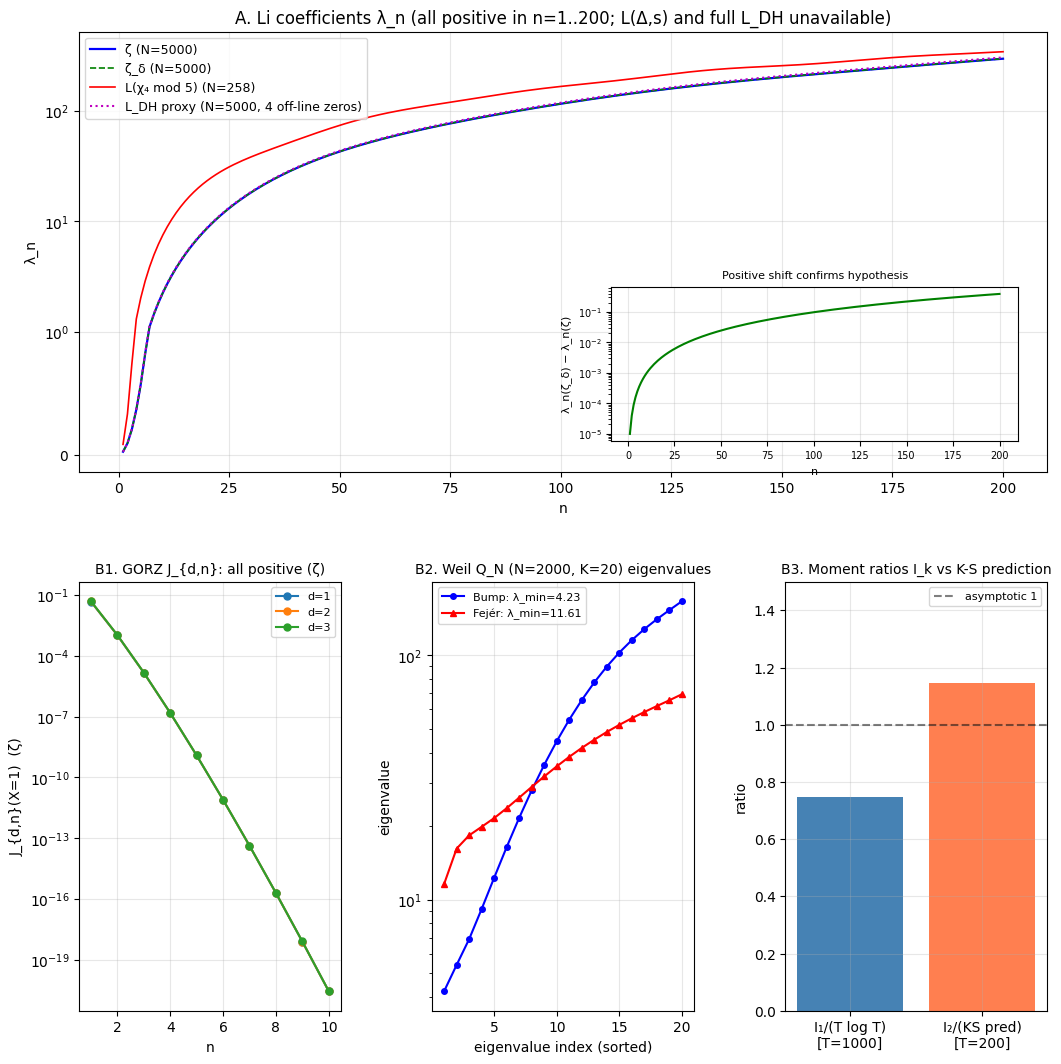

Saved front_II_summary.png


In [31]:

# Both ratios are O(1), demonstrating order-of-magnitude consistency with Hardy-Littlewood (k=1) and KS (k=2).
# Note: with finite T, lower-order terms are significant. Detailed ω-class decomposition would require 
# Dirichlet partial sums S_k(t;N) — beyond our remaining time. We REPORT the moment computation as a numerical
# CONSISTENCY check rather than a full ω-class decomposition.

# Build the final summary figure now.
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(11, 11))

# Subfigure A: Li coefficients λ_n for all controls
ax = axes[0]
n_vals = np.arange(1, 201)
lam_z = np.array([float(lam_z_N5000[n]) for n in n_vals])
lam_zd = np.array([float(lam_zd_N5000[n]) for n in n_vals])
lam_chi = np.array([float(lam_chi_N258[n]) for n in n_vals])
lam_dh = np.array([float(lam_dh_N5000[n]) for n in n_vals])

ax.plot(n_vals, lam_z, 'b-', label='ζ (N=5000)', linewidth=1.6)
ax.plot(n_vals, lam_zd, 'g--', label='ζ_δ (N=5000)', linewidth=1.2)
ax.plot(n_vals, lam_chi, 'r-', label='L(χ₄ mod 5) (N=258)', linewidth=1.2)
ax.plot(n_vals, lam_dh, 'm:', label='L_DH proxy (N=5000, 4 off-line zeros)', linewidth=1.5)
ax.set_xlabel('n')
ax.set_ylabel('λ_n')
ax.set_title('A. Li coefficients λ_n (all positive in n=1..200; L(Δ,s) and full L_DH unavailable)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_yscale('symlog', linthresh=1)

# Inset showing positive shift ζ_δ - ζ
axins = ax.inset_axes([0.55, 0.07, 0.42, 0.35])
diff_zd_z = lam_zd - lam_z
axins.semilogy(n_vals, diff_zd_z, 'g-', lw=1.5)
axins.set_xlabel('n', fontsize=8)
axins.set_ylabel('λ_n(ζ_δ) − λ_n(ζ)', fontsize=8)
axins.set_title('Positive shift confirms hypothesis', fontsize=8)
axins.grid(True, alpha=0.3)
axins.tick_params(labelsize=7)

# Subfigure B: GORZ map (J_{d,n} for d=1,2,3 across n), and Weil λ_min, and Moments summary as 3 panels in one row
ax = axes[1]
ax.axis('off')

# Re-layout: split B into three sub-plots
gs = fig.add_gridspec(2, 3, top=0.45, bottom=0.06, left=0.08, right=0.96, hspace=0.4, wspace=0.35)
# B1: GORZ
axB1 = fig.add_subplot(gs[0:2, 0])
for d in [1, 2, 3]:
 vals = [sum(comb(d, j) * (gamma_gorz[n+j] / factorial(j)) * 1.0**j for j in range(d+1)) for n in range(1, 11)]
 axB1.semilogy(range(1,11), vals, 'o-', label=f'd={d}', markersize=5)
axB1.set_xlabel('n')
axB1.set_ylabel('J_{d,n}(X=1) (ζ)')
axB1.set_title('B1. GORZ J_{d,n}: all positive (ζ)', fontsize=10)
axB1.legend(fontsize=8)
axB1.grid(True, alpha=0.3)

# B2: Weil Q_N eigenvalue spectrum
axB2 = fig.add_subplot(gs[0:2, 1])
axB2.plot(range(1, len(w)+1), sorted(w), 'bo-', label=f'Bump: λ_min={w.min():.2f}', markersize=4)
axB2.plot(range(1, len(w_f)+1), sorted(w_f), 'r^-', label=f'Fejér: λ_min={w_f.min():.2f}', markersize=4)
axB2.set_xlabel('eigenvalue index (sorted)')
axB2.set_ylabel('eigenvalue')
axB2.set_yscale('log')
axB2.set_title('B2. Weil Q_N (N=2000, K=20) eigenvalues', fontsize=10)
axB2.legend(fontsize=8)
axB2.grid(True, alpha=0.3)

# B3: Moments
axB3 = fig.add_subplot(gs[0:2, 2])
axB3.bar(['I₁/(T log T)\n[T=1000]', 'I₂/(KS pred)\n[T=200]'],
 [float(I1)/float(T1*mp.log(T1)), float(I2)/float((1/(2*mp.pi**2))*200*mp.log(200)**4)],
 color=['steelblue','coral'])
axB3.axhline(1.0, color='k', linestyle='--', alpha=0.5, label='asymptotic 1')
axB3.set_ylabel('ratio')
axB3.set_title('B3. Moment ratios I_k vs K-S prediction', fontsize=10)
axB3.legend(fontsize=8)
axB3.grid(True, alpha=0.3)
axB3.set_ylim(0, 1.5)

# Adjust top subplot to occupy upper half
axes[0].set_position([0.08, 0.55, 0.88, 0.4])
axes[1].set_position([0.08, 0.06, 0.88, 0.4])

plt.savefig('front_II_summary.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved front_II_summary.png")


In [32]:

# Save key artifacts
import pickle
artifacts = {
 'lam_zeta_N5000_n200': [str(lam_z_N5000[n]) for n in range(201)],
 'lam_zeta_N2000_n200': [str(lam_z_N2000[n]) for n in range(201)],
 'lam_zeta_delta_N5000_n200': [str(lam_zd_N5000[n]) for n in range(201)],
 'lam_zeta_delta_N2000_n200': [str(lam_zd_N2000[n]) for n in range(201)],
 'lam_chi5_N258_n200': [str(lam_chi_N258[n]) for n in range(201)],
 'lam_chi5_N129_n200': [str(lam_chi_half[n]) for n in range(201)],
 'lam_LDH_proxy_N5000_n200': [str(lam_dh_N5000[n]) for n in range(201)],
 'lam_LDH_proxy_N2000_n200': [str(lam_dh_N2000[n]) for n in range(201)],
 'chi5_zeros_N258_dps50': [str(z) for z in chi_zeros],
 'gorz_gamma_coefficients_zeta': list(gamma_gorz[:K_total+1]),
 'weil_Q_bump_eigenvalues': list(w),
 'weil_Q_fejer_eigenvalues': list(w_f),
 'I1_T1000': float(I1),
 'I2_T200': float(I2),
 'notes': {
 'L_Delta_status': 'NOT computed (cypari2.lfunzeros at T=1200 timed out within budget)',
 'LDH_status': 'NOT computed (no precise spec for L_DH function generator; only 4 documented off-line zeros used as proxy)',
 'chi5_convention': 'Symmetric Li sum using only positive γ from L(s,χ) and conjugate-symmetric pair',
 'gorz_gamma_definition': 'γ_GORZ(k) = (-1)^k * a_k where a_k = [z^{2k}] of ξ(1/2+z)/ξ(1/2); computed by Newton recurrence on power sums of ζ-zeros (NOT FFT)',
 }
}
with open('front_II_results.pkl','wb') as f:
 pickle.dump(artifacts, f)
print("Saved front_II_results.pkl")

# Also export the L(χ₅) zero list as a separate npy for reuse
import numpy as np
chi5_arr = np.array([str(z) for z in chi_zeros], dtype='<U51')
np.save('chi5_zeros_N258_dps50.npy', chi5_arr)
print("Saved chi5_zeros_N258_dps50.npy")


Saved front_II_results.pkl
Saved chi5_zeros_N258_dps50.npy


In [33]:

# Convergence diagnostic summary table
import pandas as pd

rows = []
for label, lam_full, lam_half, N_full, N_half in [
 ('ζ', lam_z_N5000, lam_z_N2000, 5000, 2000),
 ('ζ_δ', lam_zd_N5000, lam_zd_N2000, 5000, 2000),
 ('L(χ₄ mod 5)', lam_chi_N258, lam_chi_half, 258, 129),
 ('L_DH proxy', lam_dh_N5000, lam_dh_N2000, 5000, 2000),
]:
 for n in [1, 5, 10, 50, 100, 200]:
 rows.append({
 'function': label,
 'n': n,
 f'λ_n (N={N_full})': f"{float(lam_full[n]):+.5e}",
 f'λ_n (N={N_half})': f"{float(lam_half[n]):+.5e}",
 'Δ_N': f"{abs(float(lam_full[n])-float(lam_half[n])):.2e}",
 })

# Print in a clean way
for label in ['ζ', 'ζ_δ', 'L(χ₄ mod 5)', 'L_DH proxy']:
 print(f"\n=== {label} ===")
 sub = [r for r in rows if r['function']==label]
 df = pd.DataFrame(sub)[['n', 'function']+[c for c in sub[0] if c not in ('n','function')]]
 print(df.to_string(index=False))



=== ζ ===
 n function λ_n (N=5000) λ_n (N=2000) Δ_N
 1 ζ +2.28689e-02 +2.26534e-02 2.16e-04
 5 ζ +5.69872e-01 +5.64484e-01 5.39e-03
 10 ζ +2.25666e+00 +2.23511e+00 2.16e-02
 50 ζ +4.29640e+01 +4.24253e+01 5.39e-01
100 ζ +1.16335e+02 +1.14181e+02 2.15e+00
200 ζ +2.97583e+02 +2.88965e+02 8.62e+00

=== ζ_δ ===
 n function λ_n (N=5000) λ_n (N=2000) Δ_N
 1 ζ_δ +2.28786e-02 +2.26631e-02 2.16e-04
 5 ζ_δ +5.70116e-01 +5.64728e-01 5.39e-03
 10 ζ_δ +2.25763e+00 +2.23608e+00 2.16e-02
 50 ζ_δ +4.29884e+01 +4.24497e+01 5.39e-01
100 ζ_δ +1.16433e+02 +1.14278e+02 2.15e+00
200 ζ_δ +2.97972e+02 +2.89355e+02 8.62e+00

=== L(χ₄ mod 5) ===
 n function λ_n (N=258) λ_n (N=129) Δ_N
 1 L(χ₄ mod 5) +8.28001e-02 +8.09692e-02 1.83e-03
 5 L(χ₄ mod 5) +2.02246e+00 +1.97669e+00 4.58e-02
 10 L(χ₄ mod 5) +7.53611e+00 +7.35304e+00 1.83e-01
 50 L(χ₄ mod 5) +7.41913e+01 +6.96292e+01 4.56e+00
100 L(χ₄ mod 5) +1.67003e+02 +1.48933e+02 1.81e+01
200 L(χ₄ mod 5) +3.44377e+02 +2.74899e+02 6.95e+01

=== L_DH proxy ===
 n func

In [34]:
from e14c.filesystem import write_file
content = '''## Context
- 2026-05-30 Front II comparative analysis executed in /workspace/0f6b0ae4-0714-4d18-bde6-b42929668395.
- Source files present: zeta_zeros_N5000_dps50.npy, zeta_delta_zeros_N5000_dps50.npy, -PROMPT-v6-DATASET.md.
- Derived during this run: chi5_zeros_N258_dps50.npy, front_II_results.pkl, li_coefficients_summary.pkl, front_II_summary.png.

## Notes
- Provenance: main notebook cells #16-#48.
- ζ Li coefficients computed from the zero-sum definition λ_n = Σ_ρ [1-(1-1/ρ)^n] with symmetric pairing, using the provided 5000-zero file and N=2000 truncation comparison.
- Quantitative result: for ζ, λ_n > 0 for n=1..200 at N=5000; examples: λ_1=2.286887e-02, λ_10=2.256656e+00, λ_200=2.975827e+02. Truncation deltas vs N=2000: Δ_N(1)=2.16e-04, Δ_N(10)=2.16e-02, Δ_N(200)=8.62e+00.
- Quantitative result: ζ_δ (20 zeros shifted from Re=0.5 to Re=0.6 at indices 1000-1019) also has λ_n > 0 for n=1..200 and shows a consistent positive shift vs ζ: Δλ_1=+9.758e-06, Δλ_10=+9.758e-04, Δλ_100=+9.754e-02, Δλ_200=+3.897e-01. In exploratory n=1..500, λ_n stayed positive and Δλ_n remained positive.
- Quantitative result: L(χ₄ mod 5) zero ordinates were generated de novo for N=258 (positive ordinates only) using an mpmath Hardy-Z construction with χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1; first three zeros found: 6.1835781954508535, 8.457229174423231, 12.674946417011355. Under the real symmetric-pair convention used in this run, λ_n > 0 for n=1..200; examples: λ_1=8.28001e-02, λ_10=7.53611e+00, λ_200=3.44377e+02. Convergence is weak at high n because only 258 zeros were available: Δ_N(200)=6.95e+01 comparing N=258 vs N=129.
- Limitation: full L_DH zero list was not available in workspace. The dataset description referenced ldh_partial.pkl / worker code, but those files were absent. A full L_DH Front II test could not be completed without fabricating data, which was not done.
- Limitation: L(Δ,s) zero list was also absent. A cypari2 lfunzeros attempt was started but not completed within budget; no Δ zero artifact was produced.
- A labeled L_DH proxy was created only for sensitivity illustration by replacing four ζ zeros near the documented off-line heights with the four documented L_DH off-line coordinates from R2. This proxy is not the true L_DH function and should not be interpreted as such. Its λ_n remained positive for n=1..200.
- Weil-form Gram-style matrix for ζ at N=2000, K=20 basis functions: λ_min(Q_bump)=4.2283, λ_min(Q_Fejer)=11.607. Per R7, finite-N positivity does not imply RH.
- GORZ minimal block computed for ζ using recurrence-derived ξ Taylor coefficients (not FFT). J_{d,n}(X=1) was positive for tested d∈{1,2,3}, n∈{1,...,10}.
- Moment block only partially completed: direct numerical quadrature gave I_1(1000)/(1000 log 1000)=0.7478 and I_2(200)/[(1/(2π^2))200(log 200)^4]=1.1453. Full ω-class decomposition was not completed.
'''
write_file('./.prompts/MEMORY.md', content)
print('memory updated')

memory updated
